# ML Model Selection

This notebook is used for selecting a best ML model to apply into BigQuery ML. Since BigQuery ML cost is high for many iterations of model training, we use local for training ML because it will not incur any cost.

We don't pick model directly from local since our goal is to use BigQuery ML. We just pick model parameters and apply it into BigQuery ML.

For reference, we will compare only 3 models:

| Machine Learning | Sklearn | BQML |
| --- | --- | --- |
| Linear Regression | `Ridge` | `LINEAR_REG` |
| Random Forest | `XGBRFRegressor` | `RANDOM_FOREST_REGRESSOR` |
| Gradient Boosting | `XGBRegressor` | `BOOSTED_TREE_REGRESSOR` |

In [50]:
# import library
from pathlib import Path
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

from scipy.stats import skew
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split

RANDOM_STATE=42

# Exploratory Data Analysis

In [4]:
# load data
path = Path.cwd() / ".." / "results" / "benchmark_results.csv"
df = pd.read_csv(path)

# show data
df.head()

,tier_months,variant,query_id,has_partition,has_cluster,table_size_bytes,partition_filter_ratio,cluster_filter_ratio,bytes_processed
0,2,none,1,False,False,1201852092,0.017544,0.047572,128179760
1,2,none,2,False,False,1201852092,0.017544,0.015565,128179760
2,2,none,3,False,False,1201852092,0.017544,0.001544,128179760
3,2,none,4,False,False,1201852092,0.017544,0.000344,128179760
4,2,none,5,False,False,1201852092,0.017544,0.000094,128179760


In [9]:
# divide columns into numerical and categorical
numerical_cols = ["table_size_bytes", "partition_filter_ratio", "cluster_filter_ratio", "bytes_processed"]
categorical_cols = ["has_partition", "has_cluster"]

# show descriptive statistics
print("Descriptive statistics for numerical columns:")
display(df[numerical_cols].describe())
print("\nDescriptive statistics for categorical columns:")
display(df[categorical_cols].describe())

# show null data
print(f"\nNull values in the dataset:\n{df.isnull().sum().sum()}")

# show duplicated values
print(f"\nDuplicated values in the dataset:\n{df.duplicated().sum()}")

Descriptive statistics for numerical columns:


,table_size_bytes,partition_filter_ratio,cluster_filter_ratio,bytes_processed
count,4.004000e+03,4004.000000,4004.000000,4.004000e+03
mean,5.142550e+09,0.288684,0.008848,2.145891e+08
std,1.806585e+09,0.261833,0.015482,2.507522e+08
min,1.201852e+09,0.002770,0.000000,1.884480e+05
25%,3.512204e+09,0.060345,0.000002,1.047894e+07
50%,5.998169e+09,0.200000,0.000340,8.972854e+07
75%,7.234807e+09,0.500000,0.015432,3.770166e+08
max,7.234807e+09,1.000000,0.047572,7.761573e+08



Descriptive statistics for categorical columns:


,has_partition,has_cluster
count,4004,4004
unique,2,2
top,False,False
freq,2002,2002



Null values in the dataset:
0

Duplicated values in the dataset:
0


Based on this data, we can see that bytes_processed have high difference in median and mean values, which indicates that the data is skewed. We need to analyze it further below.

Besides that, has_partition and has_clustered are boolean values. BQML will encoding this feature into 0 and 1. We need to do same encoding to make exact same model performance.

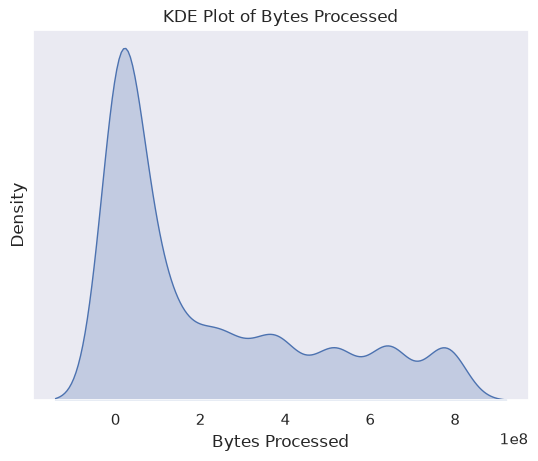

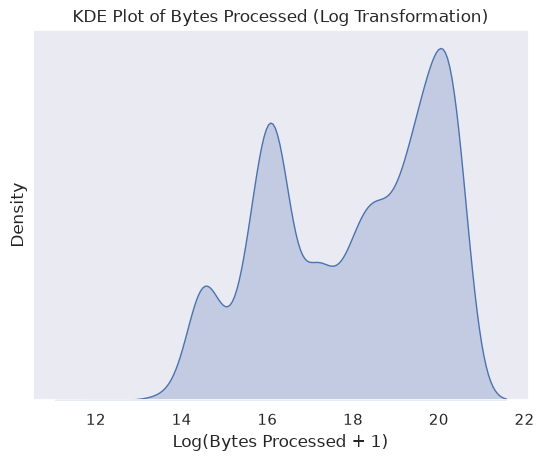

Skewness of bytes_processed: 1.01
Skewness of log_bytes_processed: -0.32


In [ ]:
# create the KDE plot for bytes_processed
sns.kdeplot(data=df, x="bytes_processed", fill=True)
plt.title("KDE Plot of Bytes Processed")
plt.xlabel("Bytes Processed")
plt.yticks([])
plt.show()

# create the KDE plot for bytes_processed after log transformation
_test = df.copy()
_test["log_bytes_processed"] = np.log1p(_test["bytes_processed"])
sns.kdeplot(data=_test, x="log_bytes_processed", fill=True)
plt.title("KDE Plot of Bytes Processed (Log Transformation)")
plt.xlabel("Log(Bytes Processed + 1)")
plt.yticks([])
plt.show()

# check skewness
print(f"Skewness of bytes_processed: {skew(df['bytes_processed']):.2f}")
print(f"Skewness of log_bytes_processed: {skew(_test['log_bytes_processed']):.2f}")

Because log transformation repair skewness, we will apply log transformation to bytes_processed. We will use log1p to avoid negative values.

# Preparation

## Data

In [39]:
# copy data
df_ml = df.copy()

# check info
df_ml[['has_partition','has_cluster']].info() # it still bool so we need to convert into int

# change into int
df_ml['has_partition'] = df_ml['has_partition'].astype(int)
df_ml['has_cluster'] = df_ml['has_cluster'].astype(int)

# check info again
print()
df_ml[['has_partition','has_cluster']].info() # now it is int

<class 'pandas.DataFrame'>
RangeIndex: 4004 entries, 0 to 4003
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   has_partition  4004 non-null   bool 
 1   has_cluster    4004 non-null   bool 
dtypes: bool(2)
memory usage: 7.9 KB

<class 'pandas.DataFrame'>
RangeIndex: 4004 entries, 0 to 4003
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   has_partition  4004 non-null   int64
 1   has_cluster    4004 non-null   int64
dtypes: int64(2)
memory usage: 62.7 KB


## Function

In [41]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """
    Evaluate model prediction. Variable y must be byte. Model prediction must be log.
    """
    p_tr = np.expm1(model.predict(X_tr))
    p_te = np.expm1(model.predict(X_te))

    r2_train = r2_score(y_tr, p_tr)
    r2_test = r2_score(y_te, p_te)
    r2_gap_pct = abs(r2_test - r2_train) / abs(r2_train) * 100

    mae_train = mean_absolute_error(y_tr, p_tr)
    mae_test = mean_absolute_error(y_te, p_te)
    mae_gap_pct = abs(mae_test - mae_train) / mae_train * 100

    if r2_train < 0.90:
        fit = "underfit"
    elif r2_gap_pct > 10:
        fit = "overfit"
    else:
        fit = "good fit"

    return {
        "r2_train": r2_train,
        "r2_test": r2_test,
        "r2_gap_pct": r2_gap_pct,
        "mae_train_mb": mae_train / 1e6,
        "mae_test_mb": mae_test / 1e6,
        "mae_gap_pct": mae_gap_pct,
        "fit": fit,
    }

def mae_scorer(model, X, y):
    """
    Scorer for CV. Variable y must be byte. Model prediction must be log.
    """
    p = np.expm1(model.predict(X))
    return -mean_absolute_error(y, p)

## Split

In [ ]:
# define feature and cluster
FEATURES = ["has_partition", "has_cluster", "table_size_bytes", "partition_filter_ratio", "cluster_filter_ratio"]
TARGET = "bytes_processed"

X = df_ml[FEATURES].copy()
y = df_ml[TARGET].copy()

# train test split
idx_train, idx_test = train_test_split(df_ml.index, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

print(f"Split into train: {X_train.shape} and test: {X_test.shape}")

Split into train: (3203, 5) and test: (801, 5)
